# Tarea 01 - Deteccion de objetos y velocidad en video

Notebook para detectar un objeto en movimiento comparando cada frame contra el frame de referencia (frame 0 / fondo).

**Pipeline:**

1. Cargar video y extraer todos los frames
2. Calcular diferencia absoluta contra el frame de referencia
3. Umbralizar + operaciones morfologicas para limpiar la mascara
4. Detectar contornos y dibujar bounding box sobre el objeto
5. Precalcular resultados para todos los frames
6. Generar GIF animado con la deteccion


## Importaciones y configuracion


In [1]:
import cv2
import io
import threading
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path
from PIL import Image as PILImage
import ipywidgets as widgets
from IPython.display import display, Image as IPImage

%matplotlib inline

## Configuracion

Parametros del pipeline en un solo lugar para facilitar el ajuste.


In [2]:
# --- Ruta al video ---
VIDEO_PATH = Path("video.mp4")
assert VIDEO_PATH.exists(
), f"No se encontro el archivo de video en: {VIDEO_PATH.resolve()}"

# --- Parametros de procesamiento ---
NUEVO_ANCHO = 680          # Redimensionar para acelerar procesamiento
NUEVO_ALTO = 480
UMBRAL_DIFF = 40           # Umbral para binarizar la diferencia absoluta
# Area minima (px^2) para considerar un contorno como objeto
AREA_MINIMA = 500
KERNEL_SIZE = (4, 4)       # Tamano del kernel morfologico
ITER_DILATE = 4            # Iteraciones de dilatacion
ITER_ERODE = 1             # Iteraciones de erosion

# --- Parámetros de corrección por aceleración ---
# Umbral en km/h/s — solo aceleraciones más suaves que este valor se usan como referencia
ACCEL_UMBRAL = 200.0

print(f"Video: {VIDEO_PATH.resolve()}")
print(f"Umbral de diferencia: {UMBRAL_DIFF}")
print(f"Area minima de contorno: {AREA_MINIMA} px^2")

Video: /home/ariasantony/Documents/Universidad/Procesamiento Digital de Imágenes/Diferencia de imágenes/90_tarea01/video.mp4
Umbral de diferencia: 40
Area minima de contorno: 500 px^2


## Carga del video

Se leen todos los frames a memoria (el video es corto, ~5 seg / 162 frames).  
Se redimensionan para acelerar el procesamiento posterior.


In [3]:
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), "Error: no se pudo abrir el video."

# Propiedades del video
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
ancho_orig = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
alto_orig = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Frames totales : {total_frames}")
print(f"FPS            : {fps:.2f}")
print(f"Resolucion     : {ancho_orig}x{alto_orig} px")
print(f"Duracion       : {total_frames / fps:.2f} seg")

# Leer todos los frames redimensionados
frames_bgr = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames_bgr.append(cv2.resize(frame, (NUEVO_ANCHO, NUEVO_ALTO)))
cap.release()

print(
    f"\nSe cargaron {len(frames_bgr)} frames redimensionados a {NUEVO_ANCHO}x{NUEVO_ALTO} px")

Frames totales : 162
FPS            : 30.00
Resolucion     : 1920x1080 px
Duracion       : 5.40 seg

Se cargaron 162 frames redimensionados a 680x480 px


## Precalculo del pipeline de deteccion

Para cada frame se calcula:

1. **Diferencia absoluta** en escala de grises contra el frame 0 (fondo)
2. **Umbralización** binaria con umbral fijo
3. **Morfología** (erosion + dilatacion) para eliminar ruido y cerrar huecos
4. **Contornos** y bounding box del objeto mas grande

Se almacena todo en listas para generar el GIF y las graficas de trayectoria.


In [4]:
# Frame de referencia (fondo) en escala de grises
frame_ref_gray = cv2.cvtColor(frames_bgr[0], cv2.COLOR_BGR2GRAY)

# Kernel para operaciones morfologicas
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, KERNEL_SIZE)

# Listas para almacenar resultados precalculados
mascaras = []          # Mascara binaria limpia por frame
bboxes = []            # Bounding box (x, y, w, h) del objeto detectado o None
frames_rgb = []        # Frame original en RGB (para matplotlib)

for i, frame_bgr in enumerate(frames_bgr):
    # 0. Convertir a RGB para visualizacion
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    frames_rgb.append(frame_rgb)

    # 1. Diferencia absoluta en escala de grises
    frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    diff = cv2.absdiff(frame_ref_gray, frame_gray)

    # 2. Umbralización binaria
    _, thresh = cv2.threshold(diff, UMBRAL_DIFF, 255, cv2.THRESH_BINARY)

    # 3. Morfología: erosion para quitar ruido, luego dilatacion para cerrar huecos
    limpia = cv2.erode(thresh, kernel, iterations=ITER_ERODE)
    limpia = cv2.dilate(limpia, kernel, iterations=ITER_DILATE)
    mascaras.append(limpia)

    # 4. Encontrar contornos y quedarse con el mas grande (el objeto)
    contornos, _ = cv2.findContours(
        limpia, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filtrar por area minima y tomar el contorno mas grande
    contornos_validos = [
        c for c in contornos if cv2.contourArea(c) >= AREA_MINIMA]
    if contornos_validos:
        mayor = max(contornos_validos, key=cv2.contourArea)
        bboxes.append(cv2.boundingRect(mayor))
    else:
        bboxes.append(None)

# Resumen
detectados = sum(1 for b in bboxes if b is not None)
print(f"Pipeline completado: {len(frames_bgr)} frames procesados")
print(f"Objeto detectado en {detectados}/{len(frames_bgr)} frames")

Pipeline completado: 162 frames procesados
Objeto detectado en 87/162 frames


## Trayectoria del objeto

Grafica de la posicion X del centro del bounding box a lo largo del tiempo.  
Esto es la base para calcular la velocidad del objeto en frames futuros.


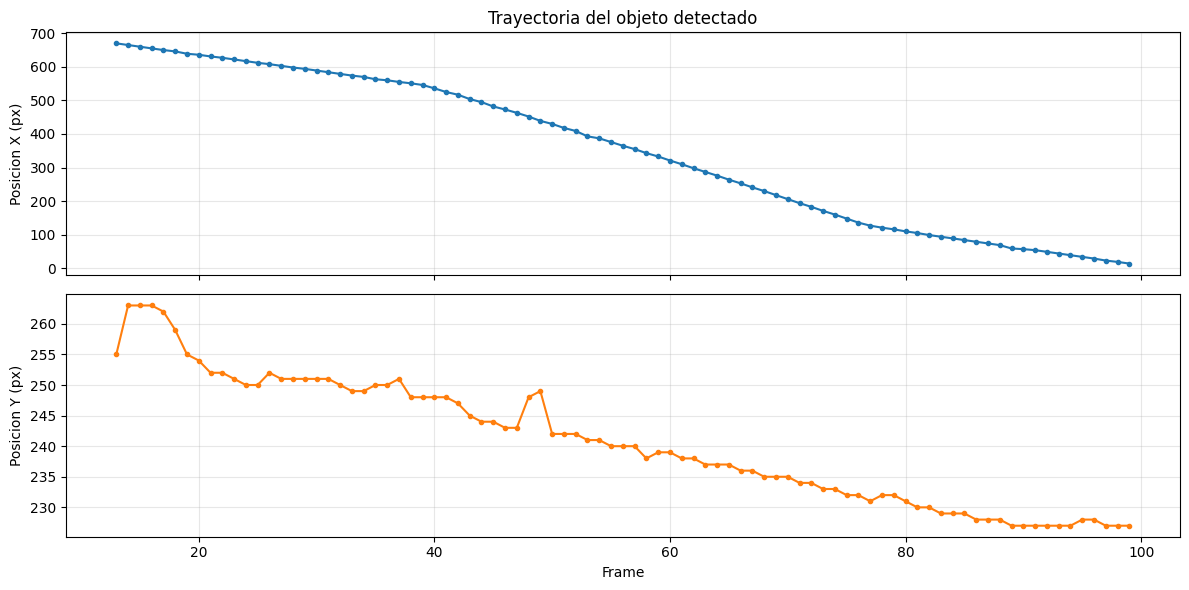

Objeto detectado en frames 13 a 99


In [5]:
plt.close('all')

# Extraer centros del bounding box donde hubo deteccion
centros_x = []
centros_y = []
frames_con_obj = []

for i, bbox in enumerate(bboxes):
    if bbox is not None:
        x, y, w, h = bbox
        centros_x.append(x + w // 2)
        centros_y.append(y + h // 2)
        frames_con_obj.append(i)

# Graficar trayectoria X e Y vs frame
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(frames_con_obj, centros_x, 'o-', color='tab:blue', markersize=3)
ax1.set_ylabel("Posicion X (px)")
ax1.set_title("Trayectoria del objeto detectado")
ax1.grid(True, alpha=0.3)

ax2.plot(frames_con_obj, centros_y, 'o-', color='tab:orange', markersize=3)
ax2.set_ylabel("Posicion Y (px)")
ax2.set_xlabel("Frame")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"Objeto detectado en frames {frames_con_obj[0]} a {frames_con_obj[-1]}" if frames_con_obj else "No se detecto objeto en ningun frame")

## Calibración de escala: metros por píxel a y=286

Se usan dos líneas de referencia horizontales a distintas profundidades de la escena
para calcular el factor de escala (metros/píxel) mediante **interpolación lineal**.

Debido a la perspectiva, objetos más lejanos (y menor en la imagen) abarcan más metros
por píxel que objetos cercanos.


ESCALAS DE REFERENCIA
  y=345:  2.2860 m / 242 px = 0.009446 m/px
  y=260:  5.8928 m / 214 px = 0.027536 m/px

INTERPOLACIÓN LINEAL
  Fórmula: escala(y) = escala_260 + (escala_345 - escala_260) × (y - 260) / (345 - 260)
  escala(286) = 0.027536 + (0.009446 - 0.027536) × (286 - 260) / (345 - 260)
  escala(286) = 0.027536 + (-0.018090) × (26 / 85)
  escala(286) = 0.027536 + (-0.005533)

  >>> Factor de escala en y=286: 0.022003 m/px <<<


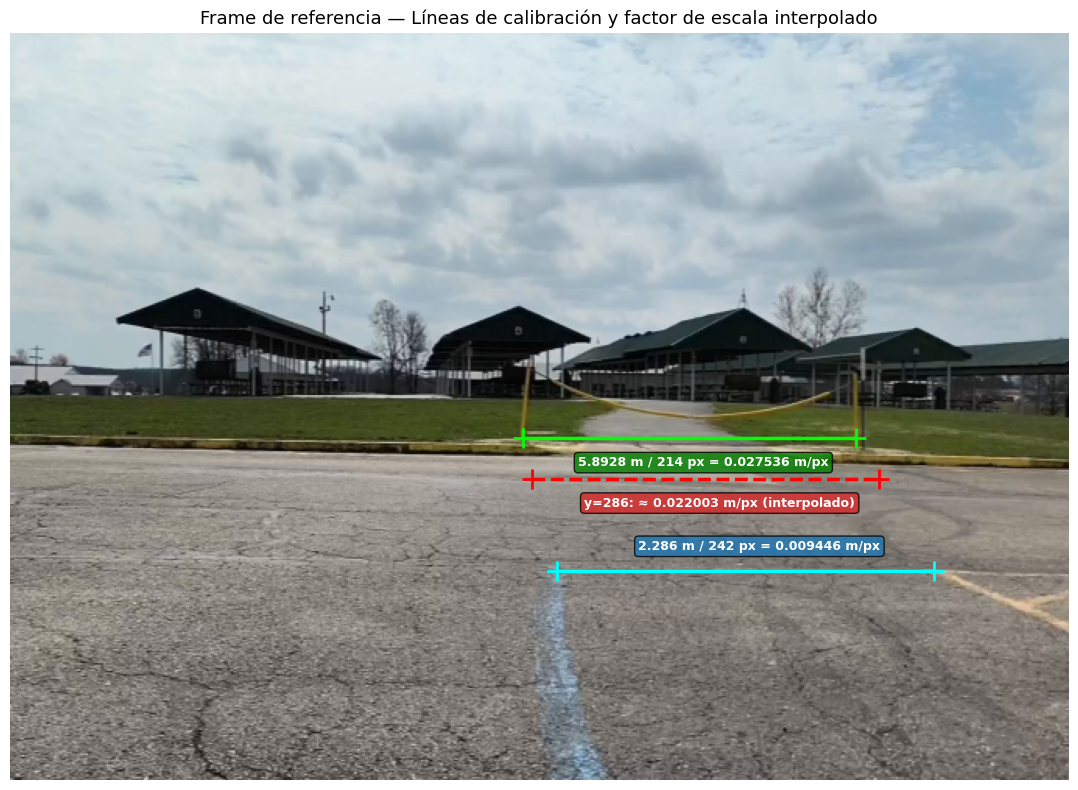

In [6]:
plt.close('all')

# =============================================================================
# Definir las dos líneas de referencia conocidas
# =============================================================================
ref = [
    {"y": 345, "x0": 351, "x1": 593, "metros": 2.286},
    {"y": 260, "x0": 329, "x1": 543, "metros": 5.8928},
]

# Calcular longitud en píxeles y escala (metros/píxel) para cada referencia
for r in ref:
    r["px"] = r["x1"] - r["x0"]
    r["escala"] = r["metros"] / r["px"]  # metros por píxel

print("=" * 60)
print("ESCALAS DE REFERENCIA")
print("=" * 60)
for r in ref:
    print(
        f"  y={r['y']:>3d}:  {r['metros']:.4f} m / {r['px']} px = {r['escala']:.6f} m/px")

# =============================================================================
# Interpolación lineal para y=286
# =============================================================================
y_objetivo = 286

# Asignar variables para claridad
# y=260 (más lejos, escala mayor)
y1, escala_1 = ref[1]["y"], ref[1]["escala"]
# y=345 (más cerca, escala menor)
y2, escala_2 = ref[0]["y"], ref[0]["escala"]

# Fórmula de interpolación lineal:
#   escala(y) = escala_260 + (escala_345 - escala_260) * (y - 260) / (345 - 260)
escala_286 = escala_1 + (escala_2 - escala_1) * (y_objetivo - y1) / (y2 - y1)

print(f"\n{'=' * 60}")
print("INTERPOLACIÓN LINEAL")
print(f"{'=' * 60}")
print(f"  Fórmula: escala(y) = escala_260 + (escala_345 - escala_260) × (y - 260) / (345 - 260)")
print(f"  escala({y_objetivo}) = {escala_1:.6f} + ({escala_2:.6f} - {escala_1:.6f}) × ({y_objetivo} - {y1}) / ({y2} - {y1})")
print(f"  escala({y_objetivo}) = {escala_1:.6f} + ({escala_2 - escala_1:.6f}) × ({y_objetivo - y1} / {y2 - y1})")
print(f"  escala({y_objetivo}) = {escala_1:.6f} + ({(escala_2 - escala_1) * (y_objetivo - y1) / (y2 - y1):.6f})")
print(f"\n  >>> Factor de escala en y={y_objetivo}: {escala_286:.6f} m/px <<<")

# =============================================================================
# Visualización sobre el frame de referencia
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(frames_rgb[0])
ax.set_title(
    "Frame de referencia — Líneas de calibración y factor de escala interpolado", fontsize=13)

# --- Línea azul: referencia en y=345 (cercana) ---
r345 = ref[0]
ax.plot([r345["x0"], r345["x1"]], [r345["y"], r345["y"]],
        '-', color='cyan', linewidth=2.5)
ax.plot(r345["x0"], r345["y"], '+', color='cyan',
        markersize=14, markeredgewidth=2)
ax.plot(r345["x1"], r345["y"], '+', color='cyan',
        markersize=14, markeredgewidth=2)
ax.annotate(
    f'{r345["metros"]:.3f} m / {r345["px"]} px = {r345["escala"]:.6f} m/px',
    xy=((r345["x0"] + r345["x1"]) / 2, r345["y"]),
    xytext=(10, 15), textcoords="offset points",
    color='white', fontsize=9, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='tab:blue', alpha=0.8),
    ha='center',
)

# --- Línea verde: referencia en y=260 (lejana) ---
r260 = ref[1]
ax.plot([r260["x0"], r260["x1"]], [r260["y"], r260["y"]],
        '-', color='lime', linewidth=2.5)
ax.plot(r260["x0"], r260["y"], '+', color='lime',
        markersize=14, markeredgewidth=2)
ax.plot(r260["x1"], r260["y"], '+', color='lime',
        markersize=14, markeredgewidth=2)
ax.annotate(
    f'{r260["metros"]:.4f} m / {r260["px"]} px = {r260["escala"]:.6f} m/px',
    xy=((r260["x0"] + r260["x1"]) / 2, r260["y"]),
    xytext=(10, -20), textcoords="offset points",
    color='white', fontsize=9, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='green', alpha=0.8),
    ha='center',
)

# --- Línea roja: interpolación en y=286 ---
# Interpolar también x0 y x1 para dibujar una línea coherente a esa altura
x0_286 = int(r260["x0"] + (r345["x0"] - r260["x0"])
             * (y_objetivo - y1) / (y2 - y1))
x1_286 = int(r260["x1"] + (r345["x1"] - r260["x1"])
             * (y_objetivo - y1) / (y2 - y1))

ax.plot([x0_286, x1_286], [y_objetivo, y_objetivo],
        '--', color='red', linewidth=2.5)
ax.plot(x0_286, y_objetivo, '+', color='red', markersize=14, markeredgewidth=2)
ax.plot(x1_286, y_objetivo, '+', color='red', markersize=14, markeredgewidth=2)
ax.annotate(
    f'y={y_objetivo}: ≈ {escala_286:.6f} m/px (interpolado)',
    xy=((x0_286 + x1_286) / 2, y_objetivo),
    xytext=(10, -20), textcoords="offset points",
    color='white', fontsize=9, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='tab:red', alpha=0.8),
    ha='center',
)

ax.axis("off")
plt.tight_layout()
plt.show()

## Cálculo de velocidad del objeto

Se calculan **dos velocidades** con distintos conjuntos de frames válidos:

**Velocidad por borde izquierdo** — frames donde `x > 0`:

- Se usa el borde izquierdo del bbox como punto de referencia.
- Incluye frames donde el objeto puede estar parcialmente cortado por el borde derecho.

**Velocidad por centro** — frames donde `x > 0` y `x + w < ancho` (objeto completamente visible):

- Se usa el centro horizontal del bbox como punto de referencia.
- Solo considera frames donde el objeto está completamente dentro del encuadre.

En ambos casos:

- Desplazamiento en píxeles → metros (con `escala_286`)
- Tiempo entre frames → `delta_frames / fps`
- Conversión final a km/h


In [ ]:
# =============================================================================
# Paso 1a: Frames válidos para velocidad por BORDE IZQUIERDO (x > 0)
# =============================================================================
frames_validos_borde = []
for i, bbox in enumerate(bboxes):
    if bbox is not None:
        x, y, w, h = bbox
        if x > 0:
            frames_validos_borde.append(i)

# =============================================================================
# Paso 1b: Frames válidos para velocidad por CENTRO (x > 0 y x+w < NUEVO_ANCHO)
# =============================================================================
frames_validos_centro = []
for i, bbox in enumerate(bboxes):
    if bbox is not None:
        x, y, w, h = bbox
        if x > 0 and (x + w) < NUEVO_ANCHO:
            frames_validos_centro.append(i)

# =============================================================================
# Paso 1c: Frames válidos para velocidad por BORDE DERECHO (x+w < NUEVO_ANCHO)
# =============================================================================
frames_validos_derecho = []
for i, bbox in enumerate(bboxes):
    if bbox is not None:
        x, y, w, h = bbox
        if (x + w) < NUEVO_ANCHO:
            frames_validos_derecho.append(i)

print(
    f"Frames con detección           : {sum(1 for b in bboxes if b is not None)}")
print(f"Frames válidos — borde izq.    : {len(frames_validos_borde)}")
print(f"Frames válidos — centro        : {len(frames_validos_centro)}")
print(f"Frames válidos — borde der.    : {len(frames_validos_derecho)}")

# =============================================================================
# Paso 2a: Velocidad por BORDE IZQUIERDO
# =============================================================================
velocidades_borde = {}

for i in range(1, len(frames_validos_borde)):
    idx_prev = frames_validos_borde[i - 1]
    idx_curr = frames_validos_borde[i]
    bbox_prev = bboxes[idx_prev]
    bbox_curr = bboxes[idx_curr]
    if bbox_prev is None or bbox_curr is None:
        continue
    delta_px = abs(bbox_curr[0] - bbox_prev[0])
    delta_m = delta_px * escala_286
    delta_t = (idx_curr - idx_prev) / fps
    velocidades_borde[idx_curr] = (
        delta_m / delta_t * 3.6) if delta_t > 0 else 0

# =============================================================================
# Paso 2b: Velocidad por CENTRO
# =============================================================================
velocidades_centro = {}

for i in range(1, len(frames_validos_centro)):
    idx_prev = frames_validos_centro[i - 1]
    idx_curr = frames_validos_centro[i]
    bbox_prev = bboxes[idx_prev]
    bbox_curr = bboxes[idx_curr]
    if bbox_prev is None or bbox_curr is None:
        continue
    cx_prev = bbox_prev[0] + bbox_prev[2] // 2
    cx_curr = bbox_curr[0] + bbox_curr[2] // 2
    delta_px = abs(cx_curr - cx_prev)
    delta_m = delta_px * escala_286
    delta_t = (idx_curr - idx_prev) / fps
    velocidades_centro[idx_curr] = (
        delta_m / delta_t * 3.6) if delta_t > 0 else 0

# =============================================================================
# Paso 2c: Velocidad por BORDE DERECHO
# =============================================================================
velocidades_derecho = {}

for i in range(1, len(frames_validos_derecho)):
    idx_prev = frames_validos_derecho[i - 1]
    idx_curr = frames_validos_derecho[i]
    bbox_prev = bboxes[idx_prev]
    bbox_curr = bboxes[idx_curr]
    if bbox_prev is None or bbox_curr is None:
        continue
    xd_prev = bbox_prev[0] + bbox_prev[2]
    xd_curr = bbox_curr[0] + bbox_curr[2]
    delta_px = abs(xd_curr - xd_prev)
    delta_m = delta_px * escala_286
    delta_t = (idx_curr - idx_prev) / fps
    velocidades_derecho[idx_curr] = (
        delta_m / delta_t * 3.6) if delta_t > 0 else 0

# =============================================================================
# Corrección de velocidades por aceleración promedio filtrada
# =============================================================================


def corregir_por_aceleracion(velocidades, fps, umbral=ACCEL_UMBRAL):
    """
    1. Calcula aceleraciones instantáneas entre frames consecutivos válidos.
    2. Conserva solo las que tienen |a| <= umbral (estables).
    3. Promedia sus valores absolutos → mean_abs_a.
    4. Corrige ÚNICAMENTE los frames outlier (|a| > umbral):
       v_corr[i] = v_corr[i-1] + signo * mean_abs_a * delta_t
       Los frames estables conservan su valor original sin cambios.
    """
    if len(velocidades) < 2:
        return dict(velocidades), {}, 0.0, 0

    frames_ord = sorted(velocidades.keys())

    # Paso 1: aceleraciones instantáneas
    acels = {}
    for i in range(1, len(frames_ord)):
        f_prev, f_curr = frames_ord[i - 1], frames_ord[i]
        delta_t = (f_curr - f_prev) / fps
        if delta_t > 0:
            acels[f_curr] = (velocidades[f_curr] -
                             velocidades[f_prev]) / delta_t

    # Paso 2: filtrar estables
    acels_estables = [a for a in acels.values() if abs(a) <= umbral]
    n_estables = len(acels_estables)

    if not acels_estables:
        return dict(velocidades), acels, 0.0, 0

    # Paso 3: promedio de valores absolutos de las aceleraciones estables
    mean_abs_a = float(np.mean([abs(a) for a in acels_estables]))

    # Paso 4: corregir SOLO los frames outlier; conservar el resto intacto
    v_corr = {frames_ord[0]: velocidades[frames_ord[0]]}
    for i in range(1, len(frames_ord)):
        f_prev, f_curr = frames_ord[i - 1], frames_ord[i]
        a_inst = acels.get(f_curr, 0.0)
        if abs(a_inst) <= umbral:
            v_corr[f_curr] = velocidades[f_curr]
        else:
            delta_t = (f_curr - f_prev) / fps
            signo = 1 if velocidades[f_curr] >= velocidades[f_prev] else -1
            v_corr[f_curr] = v_corr[f_prev] + signo * mean_abs_a * delta_t

    return v_corr, acels, mean_abs_a, n_estables


# Aplicar a las tres series
velocidades_borde,   acels_borde,   maa_borde,   nf_b = corregir_por_aceleracion(
    velocidades_borde,   fps)
velocidades_centro,  acels_centro,  maa_centro,  nf_c = corregir_por_aceleracion(
    velocidades_centro,  fps)
velocidades_derecho, acels_derecho, maa_derecho, nf_d = corregir_por_aceleracion(
    velocidades_derecho, fps)

n_out_b = sum(1 for a in acels_borde.values() if abs(a) > ACCEL_UMBRAL)
n_out_c = sum(1 for a in acels_centro.values() if abs(a) > ACCEL_UMBRAL)
n_out_d = sum(1 for a in acels_derecho.values() if abs(a) > ACCEL_UMBRAL)

print(f"\n{'=' * 60}")
print("CORRECCIÓN POR ACELERACIÓN")
print(f"{'=' * 60}")
print(f"  Umbral               : {ACCEL_UMBRAL} km/h/s")
print(
    f"  Borde izq.  — mean|a|: {maa_borde:.4f} km/h/s  ({nf_b} estables, {n_out_b} corregidos)")
print(
    f"  Centro      — mean|a|: {maa_centro:.4f} km/h/s  ({nf_c} estables, {n_out_c} corregidos)")
print(
    f"  Borde der.  — mean|a|: {maa_derecho:.4f} km/h/s  ({nf_d} estables, {n_out_d} corregidos)")

# =============================================================================
# Promedios (sobre velocidades ya corregidas)
# =============================================================================
velocidad_promedio_borde = np.mean(
    list(velocidades_borde.values())) if velocidades_borde else 0.0
velocidad_promedio_centro = np.mean(
    list(velocidades_centro.values())) if velocidades_centro else 0.0
velocidad_promedio_derecho = np.mean(
    list(velocidades_derecho.values())) if velocidades_derecho else 0.0

# =============================================================================
# Resumen
# =============================================================================
for titulo, vels, prom in [
    ("VELOCIDAD POR BORDE IZQUIERDO", velocidades_borde,   velocidad_promedio_borde),
    ("VELOCIDAD POR CENTRO",          velocidades_centro,  velocidad_promedio_centro),
    ("VELOCIDAD POR BORDE DERECHO",   velocidades_derecho, velocidad_promedio_derecho),
]:
    print(f"\n{'=' * 60}")
    print(titulo)
    print(f"{'=' * 60}")
    if vels:
        vals = list(vels.values())
        print(f"  Mínima   : {min(vals):.2f} km/h")
        print(f"  Máxima   : {max(vals):.2f} km/h")
        print(f"  Promedio : {prom:.2f} km/h")
    else:
        print("  No se pudieron calcular velocidades.")

Frames con detección           : 87
Frames válidos — borde izq.    : 64
Frames válidos — centro        : 37
Frames válidos — borde der.    : 60

CORRECCIÓN POR ACELERACIÓN
  Umbral               : 200.0 km/h/s
  Borde izq.  — mean|a|: 55.2859 km/h/s  (49 estables, 13 corregidos)
  Centro      — mean|a|: 68.3193 km/h/s  (24 estables, 11 corregidos)
  Borde der.  — mean|a|: 58.8140 km/h/s  (40 estables, 18 corregidos)

VELOCIDAD POR BORDE IZQUIERDO
  Mínima   : 11.88 km/h
  Máxima   : 42.73 km/h
  Promedio : 28.55 km/h

VELOCIDAD POR CENTRO
  Mínima   : 14.26 km/h
  Máxima   : 38.02 km/h
  Promedio : 28.19 km/h

VELOCIDAD POR BORDE DERECHO
  Mínima   : 11.88 km/h
  Máxima   : 47.53 km/h
  Promedio : 28.24 km/h


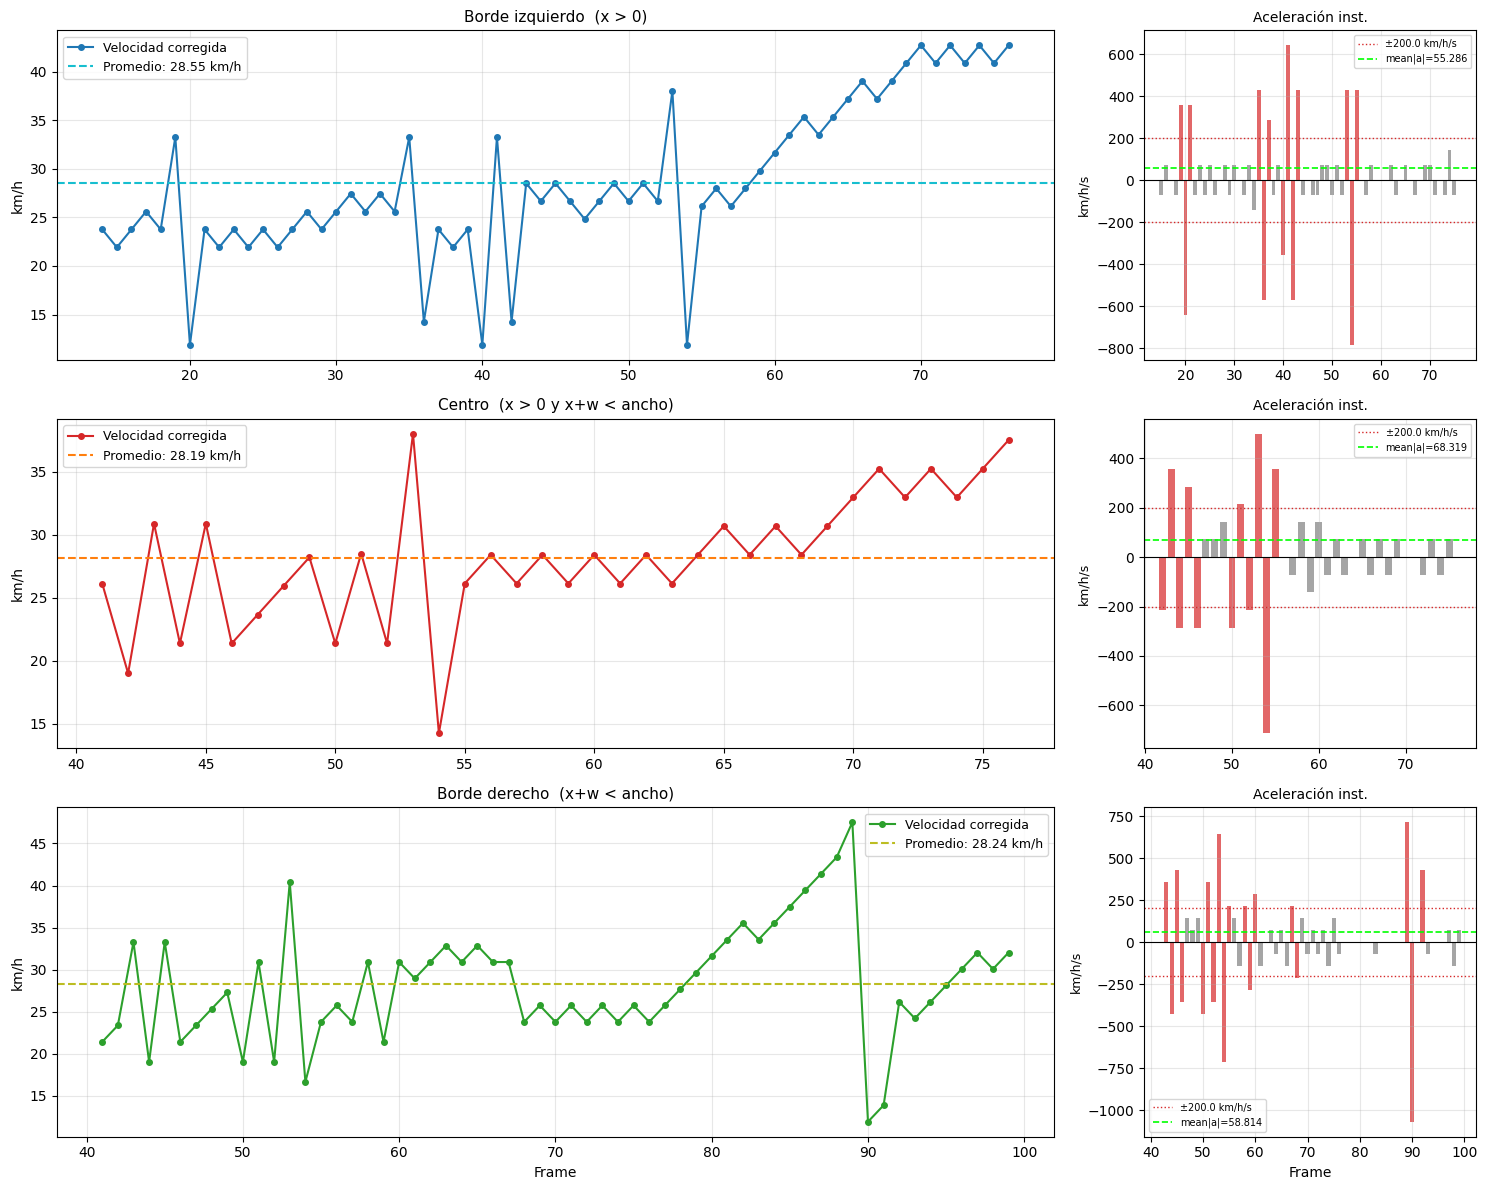

In [8]:
plt.close('all')

fig, axes = plt.subplots(3, 2, figsize=(15, 12),
                         gridspec_kw={"width_ratios": [3, 1]})

series = [
    ("Borde izquierdo  (x > 0)",         velocidades_borde,
     acels_borde,   maa_borde,   "tab:blue",  "tab:cyan"),
    ("Centro  (x > 0 y x+w < ancho)",    velocidades_centro,
     acels_centro,  maa_centro,  "tab:red",   "tab:orange"),
    ("Borde derecho  (x+w < ancho)",      velocidades_derecho,
     acels_derecho, maa_derecho, "tab:green", "tab:olive"),
]

for row, (titulo, vels, acels, maa, col_v, col_p) in enumerate(series):
    ax_v = axes[row, 0]
    ax_a = axes[row, 1]

    if vels:
        fv = sorted(vels.keys())
        vv = [vels[f] for f in fv]
        prom = np.mean(vv)
        ax_v.plot(fv, vv, 'o-', color=col_v, markersize=4,
                  label='Velocidad corregida')
        ax_v.axhline(prom, color=col_p, linestyle='--', linewidth=1.5,
                     label=f'Promedio: {prom:.2f} km/h')
    ax_v.set_ylabel("km/h", fontsize=10)
    ax_v.set_title(titulo, fontsize=11)
    ax_v.legend(fontsize=9)
    ax_v.grid(True, alpha=0.3)
    if row == 2:
        ax_v.set_xlabel("Frame", fontsize=10)

    if acels:
        fa = sorted(acels.keys())
        va = [acels[f] for f in fa]
        colores_a = ['tab:gray' if abs(
            a) <= ACCEL_UMBRAL else 'tab:red' for a in va]
        ax_a.bar(fa, va, color=colores_a, alpha=0.7, width=0.8)
        ax_a.axhline(0, color='black', linewidth=0.8)
        ax_a.axhline(ACCEL_UMBRAL, color='tab:red', linestyle=':', linewidth=1)
        ax_a.axhline(-ACCEL_UMBRAL, color='tab:red', linestyle=':', linewidth=1,
                     label=f'±{ACCEL_UMBRAL} km/h/s')
        ax_a.axhline(maa, color='lime', linestyle='--', linewidth=1.2,
                     label=f'mean|a|={maa:.3f}')
    ax_a.set_ylabel("km/h/s", fontsize=9)
    ax_a.set_title("Aceleración inst.", fontsize=10)
    ax_a.legend(fontsize=7)
    ax_a.grid(True, alpha=0.3)
    if row == 2:
        ax_a.set_xlabel("Frame", fontsize=10)

plt.tight_layout()
plt.show()

## GIF animado de la detección con velocidad

Se genera un GIF que muestra 3 paneles simultáneos para cada frame:

- **Original**: frame RGB
- **Máscara**: resultado de diferencia + umbral + morfología
- **Detección**: frame con bounding box del objeto detectado

Cada frame incluye un **pie de foto** con la velocidad instantánea (si fue calculada) y el promedio general.


In [ ]:
plt.close('all')

frames_gif = []

for i in range(len(frames_rgb)):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(frames_rgb[i])
    axes[0].set_title(f'Frame {i} - Original')
    axes[0].axis('off')

    axes[1].imshow(mascaras[i], cmap='gray')
    axes[1].set_title('Máscara')
    axes[1].axis('off')

    axes[2].imshow(frames_rgb[i])
    bbox = bboxes[i]
    if bbox is not None:
        x, y, w, h = bbox
        axes[2].add_patch(Rectangle((x, y), w, h, linewidth=2,
                          edgecolor='lime', facecolor='none'))
        cx, cy = x + w // 2, y + h // 2
        axes[2].plot(cx, cy, '+', color='red',
                     markersize=10, markeredgewidth=2)
        axes[2].set_title(f'Detección — centro: ({cx}, {cy})')
    else:
        axes[2].set_title('Sin detección')
    axes[2].axis('off')

    vel_b = f"{velocidades_borde[i]:.2f}" if i in velocidades_borde else "—"
    vel_c = f"{velocidades_centro[i]:.2f}" if i in velocidades_centro else "—"
    vel_d = f"{velocidades_derecho[i]:.2f}" if i in velocidades_derecho else "—"

    fig.text(
        0.5, 0.02,
        f"Izq.: {vel_b} km/h (p. {velocidad_promedio_borde:.2f})  |  "
        f"Centro: {vel_c} km/h (p. {velocidad_promedio_centro:.2f})  |  "
        f"Der.: {vel_d} km/h (p. {velocidad_promedio_derecho:.2f})",
        ha='center', fontsize=10, color='white',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7)
    )

    plt.tight_layout(rect=[0, 0.06, 1, 1])

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=80)
    buf.seek(0)
    frames_gif.append(PILImage.open(buf).copy())
    plt.close(fig)

gif_path = 'velocidad.gif'
frames_gif[0].save(
    gif_path,
    save_all=True,
    append_images=frames_gif[1:],
    duration=100,
    loop=0
)

print(f"GIF guardado en: {gif_path} ({len(frames_gif)} frames)")
IPImage(gif_path)

## Visor interactivo

Panel de exploración frame a frame con controles de reproducción, ajuste de parámetros y marcadores manuales.


In [ ]:
%matplotlib widget

# ── Estado global ────────────────────────────────────────────────────────────
estado = {
    "frame": 0,
    "reproduciendo": False,
    "marcadores": [],
    "umbral": UMBRAL_DIFF,
    "erosion": ITER_ERODE,
    "dilatacion": ITER_DILATE,
}

N = len(frames_rgb)
kernel_base = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, KERNEL_SIZE)

def calcular_mascara(frame_idx, umbral, erosion, dilatacion):
    frame_gray = cv2.cvtColor(frames_bgr[frame_idx], cv2.COLOR_BGR2GRAY)
    diff = cv2.absdiff(frame_ref_gray, frame_gray)
    _, thresh = cv2.threshold(diff, umbral, 255, cv2.THRESH_BINARY)
    limpia = cv2.erode(thresh, kernel_base, iterations=erosion)
    limpia = cv2.dilate(limpia, kernel_base, iterations=dilatacion)
    return limpia

# ── Widgets ───────────────────────────────────────────────────────────────────
radio_vista = widgets.RadioButtons(
    options=["Original", "Máscara"], value="Original",
    description="Vista:", layout=widgets.Layout(width="150px"),
)
chk_calibracion = widgets.Checkbox(value=False, description="Líneas de calibración",
    indent=False, layout=widgets.Layout(width="220px"))
chk_bbox = widgets.Checkbox(value=False, description="Bounding box",
    indent=False, layout=widgets.Layout(width="180px"))
sl_umbral   = widgets.IntSlider(value=UMBRAL_DIFF, min=1,  max=100, step=1,
    description="Umbral:",    continuous_update=True, layout=widgets.Layout(width="350px"))
sl_erosion  = widgets.IntSlider(value=ITER_ERODE,  min=0,  max=10,  step=1,
    description="Erosión:",   continuous_update=True, layout=widgets.Layout(width="350px"))
sl_dilatacion = widgets.IntSlider(value=ITER_DILATE, min=0, max=10, step=1,
    description="Dilatación:", continuous_update=True, layout=widgets.Layout(width="350px"))
sl_frame = widgets.IntSlider(value=0, min=0, max=N-1, step=1,
    description="Frame:", continuous_update=True, layout=widgets.Layout(width="500px"))
btn_prev  = widgets.Button(description="◀ Anterior",   layout=widgets.Layout(width="110px"))
btn_play  = widgets.Button(description="▶ Play",        layout=widgets.Layout(width="110px"))
btn_next  = widgets.Button(description="Siguiente ▶",  layout=widgets.Layout(width="110px"))
btn_clear = widgets.Button(description="Limpiar marcadores", button_style="warning",
    layout=widgets.Layout(width="160px"))
lbl_info = widgets.Label(value="")

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(left=0.05, right=0.95, top=0.93, bottom=0.05)
fig.canvas.header_visible = False

def dibujar(frame_idx):
    ax.cla()
    vista = radio_vista.value

    if vista == "Original":
        ax.imshow(frames_rgb[frame_idx])
    else:
        ax.imshow(calcular_mascara(frame_idx, sl_umbral.value,
                                   sl_erosion.value, sl_dilatacion.value), cmap="gray")

    if chk_bbox.value:
        bbox = bboxes[frame_idx]
        if bbox is not None:
            x, y, w, h = bbox
            ax.add_patch(Rectangle((x, y), w, h, linewidth=2,
                         edgecolor="lime", facecolor="none"))
            ax.plot(x + w//2, y + h//2, "+", color="red", markersize=10, markeredgewidth=2)

    if chk_calibracion.value:
        r345, r260 = ref[0], ref[1]
        ax.plot([r345["x0"], r345["x1"]], [r345["y"], r345["y"]], "-", color="cyan", linewidth=2)
        ax.annotate(f'{r345["metros"]:.3f} m / {r345["px"]} px',
            xy=((r345["x0"]+r345["x1"])/2, r345["y"]), xytext=(0, 8),
            textcoords="offset points", color="white", fontsize=8, fontweight="bold", ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="tab:blue", alpha=0.8))
        ax.plot([r260["x0"], r260["x1"]], [r260["y"], r260["y"]], "-", color="lime", linewidth=2)
        ax.annotate(f'{r260["metros"]:.4f} m / {r260["px"]} px',
            xy=((r260["x0"]+r260["x1"])/2, r260["y"]), xytext=(0, -14),
            textcoords="offset points", color="white", fontsize=8, fontweight="bold", ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="green", alpha=0.8))
        ax.plot([x0_286, x1_286], [y_objetivo, y_objetivo], "--", color="red", linewidth=2)
        ax.annotate(f"y={y_objetivo} (interpolado)",
            xy=((x0_286+x1_286)/2, y_objetivo), xytext=(0, -14),
            textcoords="offset points", color="white", fontsize=8, fontweight="bold", ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="tab:red", alpha=0.8))

    for m_frame, mx, my in estado["marcadores"]:
        if m_frame == frame_idx:
            ax.plot(mx, my, "x", color="yellow", markersize=12, markeredgewidth=2.5)
            ax.annotate(f"({mx}, {my})", xy=(mx, my), xytext=(6, -10),
                textcoords="offset points", color="yellow", fontsize=7)

    vel_b = velocidades_borde.get(frame_idx)
    vel_c = velocidades_centro.get(frame_idx)
    vel_d = velocidades_derecho.get(frame_idx)
    partes = []
    if vel_b is not None: partes.append(f"Izq: {vel_b:.2f} km/h")
    if vel_c is not None: partes.append(f"Centro: {vel_c:.2f} km/h")
    if vel_d is not None: partes.append(f"Der: {vel_d:.2f} km/h")
    titulo = f"Frame {frame_idx}/{N-1}"
    if partes:
        titulo += "  |  " + "   ".join(partes)
    ax.set_title(titulo, fontsize=11)
    ax.axis("off")
    fig.canvas.draw_idle()

    n_m = sum(1 for m in estado["marcadores"] if m[0] == frame_idx)
    lbl_info.value = f"Marcadores en este frame: {n_m}  |  Total: {len(estado['marcadores'])}"

# ── Callbacks ─────────────────────────────────────────────────────────────────
def on_frame_change(change):
    estado["frame"] = change["new"]
    dibujar(estado["frame"])

def on_param_change(change):
    dibujar(estado["frame"])

def on_prev(_):  sl_frame.value = max(0, estado["frame"] - 1)
def on_next(_):  sl_frame.value = min(N - 1, estado["frame"] + 1)

def on_play(_):
    if estado["reproduciendo"]:
        estado["reproduciendo"] = False
        btn_play.description = "▶ Play"
    else:
        estado["reproduciendo"] = True
        btn_play.description = "⏸ Pausa"
        def _loop():
            while estado["reproduciendo"]:
                nuevo = (estado["frame"] + 1) % N
                sl_frame.value = nuevo
                if nuevo == 0:
                    estado["reproduciendo"] = False
                    btn_play.description = "▶ Play"
                    break
                time.sleep(1.0 / fps)
        threading.Thread(target=_loop, daemon=True).start()

def on_clear(_):
    estado["marcadores"].clear()
    dibujar(estado["frame"])

def on_click(event):
    if event.inaxes == ax and event.xdata is not None:
        mx, my = int(round(event.xdata)), int(round(event.ydata))
        estado["marcadores"].append((estado["frame"], mx, my))
        dibujar(estado["frame"])

sl_frame.observe(on_frame_change, names="value")
for w in [sl_umbral, sl_erosion, sl_dilatacion, radio_vista, chk_calibracion, chk_bbox]:
    w.observe(on_param_change, names="value")
btn_prev.on_click(on_prev)
btn_play.on_click(on_play)
btn_next.on_click(on_next)
btn_clear.on_click(on_clear)
fig.canvas.mpl_connect("button_press_event", on_click)

# ── Layout ────────────────────────────────────────────────────────────────────
display(widgets.VBox([
    widgets.HBox([radio_vista, chk_calibracion, chk_bbox]),
    widgets.VBox([sl_umbral, sl_erosion, sl_dilatacion]),
    sl_frame,
    widgets.HBox([btn_prev, btn_play, btn_next, btn_clear]),
    lbl_info,
]))
dibujar(0)